# Train Both RidgeVision Models Again, Then Ensemble

This notebook trains two models from scratch on the **same train/validation/test split**:

- Model 1: EfficientNetB0, 224x224 image input, original 30 texture features
- Model 2: EfficientNetB3, 300x300 image input, multi-LBP texture features

After training, it saves both models separately and combines their predictions with soft voting.

In [1]:
# Kaggle dependency cell. Uncomment only if needed.
# !pip install -q scikit-image seaborn

In [2]:
import os
import gc
from pathlib import Path

import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from skimage.measure import shannon_entropy

print('TensorFlow:', tf.__version__)
print('GPUs:', tf.config.list_physical_devices('GPU'))

2026-06-04 05:34:18.989865: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780551259.207012      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780551259.262943      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780551259.735162      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780551259.735193      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780551259.735196      58 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# =========================
# CONFIG
# =========================

OUTPUT_DIR = Path('/kaggle/working')
REPORT_DIR = OUTPUT_DIR / 'report_images'
REPORT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_LABELS = ['A+', 'A-', 'AB+', 'AB-', 'B+', 'B-', 'O+', 'O-']
LABEL_TO_INDEX = {label: i for i, label in enumerate(CLASS_LABELS)}

# Set DATASET_DIR manually only if auto-detection does not find your dataset.
# Correct examples often look like:
# DATASET_DIR = Path('/kaggle/input/finger-print-based-blood-group-dataset/dataset_blood_group')
# DATASET_DIR = Path('/kaggle/input/blood-group-dataset/dataset_blood_group')
DATASET_DIR = None

SEED = 42
BATCH_SIZE = 16

# You can reduce these for a quick run, then increase for final training.
EPOCHS_HEAD_88 = 5
EPOCHS_FINE_88 = 15
EPOCHS_HEAD_91 = 15
EPOCHS_FINE_91 = 60

MODEL_88_PATH = OUTPUT_DIR / 'ridgevision_b0_88_style_best.keras'
MODEL_91_PATH = OUTPUT_DIR / 'ridgevision_b3_91_style_best.keras'
FINAL_ENSEMBLE_REPORT = REPORT_DIR / 'ridgevision_train_both_ensemble_report.txt'

np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Output dir:', OUTPUT_DIR)

Output dir: /kaggle/working


In [4]:
# =========================
# FIND AND INDEX DATASET: ONE COMMON SPLIT FOR BOTH MODELS
# =========================

def find_dataset_dir():
    if DATASET_DIR is not None:
        manual_path = Path(DATASET_DIR)
        if manual_path.exists():
            return manual_path
        raise FileNotFoundError(f'Manual DATASET_DIR does not exist: {manual_path}')

    search_roots = [Path('/kaggle/input'), Path('/kaggle/working')]
    candidates = []

    for root in search_roots:
        if not root.exists():
            continue
        for path in root.rglob('*'):
            if not path.is_dir():
                continue
            class_folder_count = sum((path / label).is_dir() for label in CLASS_LABELS)
            if class_folder_count >= 6:
                candidates.append((class_folder_count, path))

    if not candidates:
        print('Could not auto-detect dataset folder.')
        print('Top folders inside /kaggle/input:')
        input_root = Path('/kaggle/input')
        if input_root.exists():
            for child in input_root.iterdir():
                print(' -', child)
        raise FileNotFoundError(
            'Dataset not found. Attach the fingerprint blood group dataset to Kaggle, '
            'or set DATASET_DIR manually to the folder that contains A+, A-, AB+, AB-, B+, B-, O+, O-.'
        )

    candidates = sorted(candidates, key=lambda item: item[0], reverse=True)
    print('Auto-detected dataset folder:', candidates[0][1])
    return candidates[0][1]


DATASET_DIR = find_dataset_dir()

image_paths = []
labels = []

for label in CLASS_LABELS:
    folder = DATASET_DIR / label
    found_for_class = []
    for ext in ['*.BMP', '*.bmp', '*.png', '*.jpg', '*.jpeg']:
        found_for_class.extend(folder.glob(ext))
    for file in found_for_class:
        image_paths.append(str(file))
        labels.append(LABEL_TO_INDEX[label])
    print(label, 'images:', len(found_for_class), 'folder:', folder)

image_paths = np.array(image_paths)
labels = np.array(labels)

print('Total images:', len(image_paths))

if len(image_paths) == 0:
    raise ValueError(
        f'No images found in {DATASET_DIR}. Check that DATASET_DIR points to the folder containing class folders.'
    )

# Fair 70/15/15 split.
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels,
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels,
)

print('Train:', len(train_paths))
print('Val:', len(val_paths))
print('Test:', len(test_paths))

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(CLASS_LABELS)),
    y=train_labels,
)
class_weights = {i: float(class_weights_array[i]) for i in range(len(CLASS_LABELS))}
print('Class weights:', class_weights)

Auto-detected dataset folder: /kaggle/input/datasets/abhiramshibaraya/fingerprint-based-blood-group-detection/dataset
A+ images: 1000 folder: /kaggle/input/datasets/abhiramshibaraya/fingerprint-based-blood-group-detection/dataset/A+
A- images: 1000 folder: /kaggle/input/datasets/abhiramshibaraya/fingerprint-based-blood-group-detection/dataset/A-
AB+ images: 1000 folder: /kaggle/input/datasets/abhiramshibaraya/fingerprint-based-blood-group-detection/dataset/AB+
AB- images: 1000 folder: /kaggle/input/datasets/abhiramshibaraya/fingerprint-based-blood-group-detection/dataset/AB-
B+ images: 1000 folder: /kaggle/input/datasets/abhiramshibaraya/fingerprint-based-blood-group-detection/dataset/B+
B- images: 1000 folder: /kaggle/input/datasets/abhiramshibaraya/fingerprint-based-blood-group-detection/dataset/B-
O+ images: 1000 folder: /kaggle/input/datasets/abhiramshibaraya/fingerprint-based-blood-group-detection/dataset/O+
O- images: 1000 folder: /kaggle/input/datasets/abhiramshibaraya/fingerpri

In [6]:
# =========================
# PREPROCESSING FUNCTIONS
# =========================

def load_cnn_image(path, img_size):
    img = cv2.imread(str(path))
    if img is None:
        return np.zeros((img_size, img_size, 3), dtype=np.float32)
    img = cv2.resize(img, (img_size, img_size))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img.astype(np.float32)


def enhance_fingerprint_gray(path, img_size):
    gray = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        return np.zeros((img_size, img_size), dtype=np.uint8)

    gray = cv2.resize(gray, (img_size, img_size))
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    gray = clahe.apply(gray)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)

    responses = []
    for theta in [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]:
        kernel = cv2.getGaborKernel(
            ksize=(21, 21),
            sigma=4.0,
            theta=theta,
            lambd=10.0,
            gamma=0.5,
            psi=0,
            ktype=cv2.CV_32F,
        )
        responses.append(cv2.filter2D(gray, cv2.CV_32F, kernel))

    enhanced = np.max(np.stack(responses, axis=0), axis=0)
    enhanced = cv2.normalize(enhanced, None, 0, 255, cv2.NORM_MINMAX)
    return enhanced.astype(np.uint8)


def common_texture_tail(gray):
    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0, np.pi / 4, np.pi / 2, 3 * np.pi / 4],
        levels=256,
        symmetric=True,
        normed=True,
    )

    props = ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation', 'ASM']
    glcm_features = []
    for prop in props:
        values = graycoprops(glcm, prop)[0]
        glcm_features.append(np.mean(values))
        glcm_features.append(np.std(values))

    edges = cv2.Canny(gray, 50, 150)
    ridge_density = np.mean(edges > 0)

    gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=3)
    magnitude = np.sqrt(gx ** 2 + gy ** 2)

    ridge_strength = np.mean(magnitude) / 255.0
    intensity_mean = np.mean(gray) / 255.0
    intensity_std = np.std(gray) / 255.0
    entropy = shannon_entropy(gray) / 8.0

    _, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    foreground_ratio = np.mean(binary > 0)

    orientation = np.arctan2(gy, gx)
    orientation_coherence = np.abs(np.mean(np.exp(1j * orientation)))
    laplacian_var = cv2.Laplacian(gray, cv2.CV_64F).var() / 10000.0

    ridge_features = np.array([
        ridge_density,
        ridge_strength,
        intensity_mean,
        intensity_std,
        entropy,
        foreground_ratio,
        orientation_coherence,
        laplacian_var,
    ])

    return np.concatenate([np.array(glcm_features), ridge_features])


def extract_texture_features_88(path):
    gray = enhance_fingerprint_gray(path, 224)
    lbp = local_binary_pattern(gray, P=8, R=1, method='uniform')
    lbp_hist, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(0, 11),
        range=(0, 10),
        density=True,
    )
    features = np.concatenate([np.nan_to_num(lbp_hist), common_texture_tail(gray)])
    return np.nan_to_num(features).astype(np.float32)


def extract_texture_features_91(path):
    gray = enhance_fingerprint_gray(path, 300)
    lbp_features = []
    for P, R in [(8, 1), (16, 2), (24, 3)]:
        lbp = local_binary_pattern(gray, P=P, R=R, method='uniform')
        hist, _ = np.histogram(
            lbp.ravel(),
            bins=np.arange(0, P + 3),
            range=(0, P + 2),
            density=True,
        )
        lbp_features.append(np.nan_to_num(hist))
    features = np.concatenate([np.concatenate(lbp_features), common_texture_tail(gray)])
    return np.nan_to_num(features).astype(np.float32)


def build_feature_matrix(paths, extractor, name):
    features = []
    print(f'Extracting texture features for {name}...')
    for i, path in enumerate(paths):
        features.append(extractor(path))
        if (i + 1) % 500 == 0:
            print(f'{name}: {i + 1}/{len(paths)}')
    return np.array(features, dtype=np.float32)

print('88 texture dim:', extract_texture_features_88(image_paths[0]).shape[0])
print('91 texture dim:', extract_texture_features_91(image_paths[0]).shape[0])

88 texture dim: 30
91 texture dim: 74


In [7]:
# =========================
# DATA GENERATOR
# =========================

class FusionDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, paths, texture_features, labels, img_size, batch_size, shuffle=True, augment=False):
        self.paths = np.array(paths)
        self.texture_features = np.array(texture_features)
        self.labels = np.array(labels)
        self.img_size = img_size
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.paths) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def augment_image(self, img):
        if np.random.rand() < 0.6:
            angle = np.random.uniform(-10, 10)
            h, w = img.shape[:2]
            matrix = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
            img = cv2.warpAffine(img, matrix, (w, h), borderMode=cv2.BORDER_REFLECT)

        if np.random.rand() < 0.6:
            alpha = np.random.uniform(0.8, 1.2)
            beta = np.random.uniform(-15, 15)
            img = cv2.convertScaleAbs(img, alpha=alpha, beta=beta).astype(np.float32)

        if np.random.rand() < 0.6:
            scale = np.random.uniform(0.85, 1.15)
            h, w = img.shape[:2]
            new_h, new_w = int(h * scale), int(w * scale)
            img_resized = cv2.resize(img, (new_w, new_h))
            if scale > 1:
                start_y = (new_h - h) // 2
                start_x = (new_w - w) // 2
                img = img_resized[start_y:start_y + h, start_x:start_x + w]
            else:
                pad_y = (h - new_h) // 2
                pad_x = (w - new_w) // 2
                img = cv2.copyMakeBorder(
                    img_resized,
                    pad_y,
                    h - new_h - pad_y,
                    pad_x,
                    w - new_w - pad_x,
                    cv2.BORDER_REFLECT,
                )

        if np.random.rand() < 0.4:
            tx = np.random.uniform(-10, 10)
            ty = np.random.uniform(-10, 10)
            matrix = np.float32([[1, 0, tx], [0, 1, ty]])
            img = cv2.warpAffine(img, matrix, (img.shape[1], img.shape[0]), borderMode=cv2.BORDER_REFLECT)

        if np.random.rand() < 0.3:
            noise = np.random.normal(0, 5, img.shape).astype(np.float32)
            img = np.clip(img + noise, 0, 255)

        return img.astype(np.float32)

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_images = []
        batch_tex = []
        batch_labels = []

        for i in batch_indices:
            img = load_cnn_image(self.paths[i], self.img_size)
            if self.augment:
                img = self.augment_image(img)
            batch_images.append(img)
            batch_tex.append(self.texture_features[i])
            batch_labels.append(self.labels[i])

        return (
            {
                'image_input': np.array(batch_images, dtype=np.float32),
                'texture_input': np.array(batch_tex, dtype=np.float32),
            },
            np.array(batch_labels, dtype=np.int32),
        )

In [8]:
# =========================
# CBAM CUSTOM LAYERS
# =========================

class ChannelAttention(tf.keras.layers.Layer):
    def __init__(self, ratio=8, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio

    def build(self, input_shape):
        channels = int(input_shape[-1])
        reduced = max(channels // self.ratio, 1)
        self.shared_dense_1 = tf.keras.layers.Dense(reduced, activation='relu')
        self.shared_dense_2 = tf.keras.layers.Dense(channels)

    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=[1, 2], keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=[1, 2], keepdims=True)
        avg_out = self.shared_dense_2(self.shared_dense_1(avg_pool))
        max_out = self.shared_dense_2(self.shared_dense_1(max_pool))
        scale = tf.nn.sigmoid(avg_out + max_out)
        return inputs * scale

    def get_config(self):
        config = super().get_config()
        config.update({'ratio': self.ratio})
        return config


class SpatialAttention(tf.keras.layers.Layer):
    def __init__(self, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.kernel_size = kernel_size
        self.conv = tf.keras.layers.Conv2D(
            filters=1,
            kernel_size=kernel_size,
            padding='same',
            activation='sigmoid',
        )

    def call(self, inputs):
        avg_pool = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        max_pool = tf.reduce_max(inputs, axis=-1, keepdims=True)
        concat = tf.concat([avg_pool, max_pool], axis=-1)
        scale = self.conv(concat)
        return inputs * scale

    def get_config(self):
        config = super().get_config()
        config.update({'kernel_size': self.kernel_size})
        return config


class CBAM(tf.keras.layers.Layer):
    def __init__(self, ratio=8, kernel_size=7, **kwargs):
        super().__init__(**kwargs)
        self.ratio = ratio
        self.kernel_size = kernel_size
        self.channel_attention = ChannelAttention(ratio)
        self.spatial_attention = SpatialAttention(kernel_size)

    def call(self, inputs):
        x = self.channel_attention(inputs)
        x = self.spatial_attention(x)
        return x

    def get_config(self):
        config = super().get_config()
        config.update({'ratio': self.ratio, 'kernel_size': self.kernel_size})
        return config

CUSTOM_OBJECTS = {
    'CBAM': CBAM,
    'ChannelAttention': ChannelAttention,
    'SpatialAttention': SpatialAttention,
}

In [9]:
# =========================
# MODEL BUILDER
# =========================

def build_fusion_model(img_size, texture_dim, backbone_name):
    image_input = tf.keras.Input(shape=(img_size, img_size, 3), name='image_input')
    texture_input = tf.keras.Input(shape=(texture_dim,), name='texture_input')

    if backbone_name == 'b0':
        backbone_cls = tf.keras.applications.EfficientNetB0
        unfreeze_from = -40
    elif backbone_name == 'b3':
        backbone_cls = tf.keras.applications.EfficientNetB3
        unfreeze_from = -80
    else:
        raise ValueError('backbone_name must be b0 or b3')

    try:
        base_model = backbone_cls(include_top=False, weights='imagenet', input_tensor=image_input)
        print(f'Using ImageNet pretrained EfficientNet{backbone_name.upper()}.')
    except Exception as e:
        print('Could not load ImageNet weights. Using weights=None.')
        print(e)
        base_model = backbone_cls(include_top=False, weights=None, input_tensor=image_input)

    base_model.trainable = False

    x = base_model.output
    x = CBAM(name='cbam_attention')(x)
    x = tf.keras.layers.GlobalAveragePooling2D(name='deep_gap')(x)
    x = tf.keras.layers.Dense(512, activation='relu', name='deep_dense')(x)
    x = tf.keras.layers.BatchNormalization(name='deep_bn')(x)
    x = tf.keras.layers.Dropout(0.35, name='deep_dropout')(x)

    y = tf.keras.layers.BatchNormalization(name='texture_bn')(texture_input)
    y = tf.keras.layers.Dense(128, activation='relu', name='texture_dense_1')(y)
    y = tf.keras.layers.BatchNormalization(name='texture_bn_2')(y)
    y = tf.keras.layers.Dropout(0.30, name='texture_dropout')(y)

    z = tf.keras.layers.Concatenate(name='feature_fusion')([x, y])
    z = tf.keras.layers.Dense(512, activation='relu', name='fusion_dense_1')(z)
    z = tf.keras.layers.BatchNormalization(name='fusion_bn_1')(z)
    z = tf.keras.layers.Dropout(0.40, name='fusion_dropout_1')(z)
    z = tf.keras.layers.Dense(256, activation='relu', name='fusion_dense_2')(z)
    z = tf.keras.layers.Dropout(0.30, name='fusion_dropout_2')(z)

    output = tf.keras.layers.Dense(len(CLASS_LABELS), activation='softmax', name='blood_group_softmax')(z)

    model = tf.keras.Model(
        inputs=[image_input, texture_input],
        outputs=output,
        name=f'RidgeVision_Fusion_CBAM_EfficientNet{backbone_name.upper()}',
    )

    return model, base_model, unfreeze_from


def make_callbacks(model_path, patience):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            model_path,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1,
        ),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=patience,
            restore_best_weights=True,
            mode='max',
            verbose=1,
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.3,
            patience=3,
            min_lr=1e-7,
            verbose=1,
        ),
    ]

In [10]:
# =========================
# TRAINING FUNCTION
# =========================

def train_one_model(
    name,
    img_size,
    train_tex,
    val_tex,
    test_tex,
    backbone_name,
    model_path,
    epochs_head,
    epochs_fine,
):
    print('\n' + '=' * 70)
    print('Training:', name)
    print('=' * 70)

    train_gen = FusionDataGenerator(train_paths, train_tex, train_labels, img_size, BATCH_SIZE, shuffle=True, augment=True)
    val_gen = FusionDataGenerator(val_paths, val_tex, val_labels, img_size, BATCH_SIZE, shuffle=False, augment=False)
    test_gen = FusionDataGenerator(test_paths, test_tex, test_labels, img_size, BATCH_SIZE, shuffle=False, augment=False)

    model, base_model, unfreeze_from = build_fusion_model(
        img_size=img_size,
        texture_dim=train_tex.shape[1],
        backbone_name=backbone_name,
    )

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    callbacks = make_callbacks(model_path, patience=12 if backbone_name == 'b0' else 20)

    print('Stage 1: training fusion head')
    history_head = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs_head,
        callbacks=callbacks,
        class_weight=class_weights,
    )

    print('Stage 2: fine-tuning backbone')
    base_model.trainable = True
    for layer in base_model.layers[:unfreeze_from]:
        layer.trainable = False
    for layer in base_model.layers:
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    history_fine = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=epochs_fine,
        callbacks=callbacks,
        class_weight=class_weights,
    )

    best_model = tf.keras.models.load_model(model_path, custom_objects=CUSTOM_OBJECTS, compile=False)
    best_model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )

    val_loss, val_acc = best_model.evaluate(val_gen, verbose=0)
    test_loss, test_acc = best_model.evaluate(test_gen, verbose=0)
    print(f'{name} validation accuracy: {val_acc:.4f}')
    print(f'{name} test accuracy: {test_acc:.4f}')
    print('Saved best model:', model_path)

    return {
        'model': best_model,
        'train_gen': train_gen,
        'val_gen': val_gen,
        'test_gen': test_gen,
        'history_head': history_head.history,
        'history_fine': history_fine.history,
        'val_acc': val_acc,
        'test_acc': test_acc,
    }

In [11]:
# =========================
# PRECOMPUTE FEATURES FOR MODEL 88 STYLE
# =========================

train_tex_88 = build_feature_matrix(train_paths, extract_texture_features_88, 'train 88')
val_tex_88 = build_feature_matrix(val_paths, extract_texture_features_88, 'val 88')
test_tex_88 = build_feature_matrix(test_paths, extract_texture_features_88, 'test 88')

print('88 texture dimension:', train_tex_88.shape[1])

Extracting texture features for train 88...
train 88: 500/5600
train 88: 1000/5600
train 88: 1500/5600
train 88: 2000/5600
train 88: 2500/5600
train 88: 3000/5600
train 88: 3500/5600
train 88: 4000/5600
train 88: 4500/5600
train 88: 5000/5600
train 88: 5500/5600
Extracting texture features for val 88...
val 88: 500/1200
val 88: 1000/1200
Extracting texture features for test 88...
test 88: 500/1200
test 88: 1000/1200
88 texture dimension: 30


In [12]:
# =========================
# TRAIN MODEL 88 STYLE: EfficientNetB0, 224, original texture
# =========================

result_88 = train_one_model(
    name='Model 88 style / EfficientNetB0',
    img_size=224,
    train_tex=train_tex_88,
    val_tex=val_tex_88,
    test_tex=test_tex_88,
    backbone_name='b0',
    model_path=MODEL_88_PATH,
    epochs_head=EPOCHS_HEAD_88,
    epochs_fine=EPOCHS_FINE_88,
)


Training: Model 88 style / EfficientNetB0


I0000 00:00:1780551945.648447      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780551945.655621      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Using ImageNet pretrained EfficientNetB0.
Stage 1: training fusion head


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5


I0000 00:00:1780551962.659969     134 service.cc:152] XLA service 0x7d0a340171b0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780551962.660013     134 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1780551962.660016     134 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1780551965.503018     134 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-04 05:46:13.236497: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 05:46:13.375072: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 05:46:13.708290: E external/local_xl

350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.3559 - loss: 2.0776
Epoch 1: val_accuracy improved from None to 0.50500, saving model to /kaggle/working/ridgevision_b0_88_style_best.keras

Epoch 1: finished saving model to /kaggle/working/ridgevision_b0_88_style_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 73s 107ms/step - accuracy: 0.4448 - loss: 1.7211 - val_accuracy: 0.5050 - val_loss: 1.2356 - learning_rate: 0.0010
Epoch 2/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5714 - loss: 1.2541
Epoch 2: val_accuracy improved from 0.50500 to 0.69667, saving model to /kaggle/working/ridgevision_b0_88_style_best.keras

Epoch 2: finished saving model to /kaggle/working/ridgevision_b0_88_style_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 27s 77ms/step - accuracy: 0.5905 - loss: 1.1822 - val_accuracy: 0.6967 - val_loss: 0.8044 - learning_rate: 0.0010
Epoch 3/5
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6287 - loss: 1.0252
Epoch 3: val_accuracy improved from 0.69667 to 0.7

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'cbam_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Model 88 style / EfficientNetB0 validation accuracy: 0.8525
Model 88 style / EfficientNetB0 test accuracy: 0.8600
Saved best model: /kaggle/working/ridgevision_b0_88_style_best.keras


In [13]:
# =========================
# PRECOMPUTE FEATURES FOR MODEL 91 STYLE
# =========================

train_tex_91 = build_feature_matrix(train_paths, extract_texture_features_91, 'train 91')
val_tex_91 = build_feature_matrix(val_paths, extract_texture_features_91, 'val 91')
test_tex_91 = build_feature_matrix(test_paths, extract_texture_features_91, 'test 91')

print('91 texture dimension:', train_tex_91.shape[1])

Extracting texture features for train 91...
train 91: 500/5600
train 91: 1000/5600
train 91: 1500/5600
train 91: 2000/5600
train 91: 2500/5600
train 91: 3000/5600
train 91: 3500/5600
train 91: 4000/5600
train 91: 4500/5600
train 91: 5000/5600
train 91: 5500/5600
Extracting texture features for val 91...
val 91: 500/1200
val 91: 1000/1200
Extracting texture features for test 91...
test 91: 500/1200
test 91: 1000/1200
91 texture dimension: 74


In [14]:
# =========================
# TRAIN MODEL 91 STYLE: EfficientNetB3, 300, multi-LBP texture
# =========================

result_91 = train_one_model(
    name='Model 91 style / EfficientNetB3',
    img_size=300,
    train_tex=train_tex_91,
    val_tex=val_tex_91,
    test_tex=test_tex_91,
    backbone_name='b3',
    model_path=MODEL_91_PATH,
    epochs_head=EPOCHS_HEAD_91,
    epochs_fine=EPOCHS_FINE_91,
)


Training: Model 91 style / EfficientNetB3
43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Using ImageNet pretrained EfficientNetB3.
Stage 1: training fusion head
Epoch 1/15


2026-06-04 06:18:59.038705: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 06:18:59.183532: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 06:18:59.576726: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 06:18:59.726876: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 06:18:59.875919: E external/local_xla/xla/stream_

350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.3059 - loss: 2.1935
Epoch 1: val_accuracy improved from None to 0.43083, saving model to /kaggle/working/ridgevision_b3_91_style_best.keras

Epoch 1: finished saving model to /kaggle/working/ridgevision_b3_91_style_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 112s 172ms/step - accuracy: 0.3357 - loss: 2.0045 - val_accuracy: 0.4308 - val_loss: 1.4215 - learning_rate: 0.0010
Epoch 2/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.4081 - loss: 1.6291
Epoch 2: val_accuracy improved from 0.43083 to 0.60833, saving model to /kaggle/working/ridgevision_b3_91_style_best.keras

Epoch 2: finished saving model to /kaggle/working/ridgevision_b3_91_style_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 50s 141ms/step - accuracy: 0.4229 - loss: 1.5417 - val_accuracy: 0.6083 - val_loss: 0.9935 - learning_rate: 0.0010
Epoch 3/15
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.4895 - loss: 1.3433
Epoch 3: val_accuracy improved from 0.60833

2026-06-04 06:34:05.177461: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 06:34:05.325568: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 06:34:05.562513: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 06:34:05.710705: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-04 06:34:06.089077: E external/local_xla/xla/stream_

350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step - accuracy: 0.7142 - loss: 0.7356
Epoch 1: val_accuracy did not improve from 0.81917
350/350 ━━━━━━━━━━━━━━━━━━━━ 125s 209ms/step - accuracy: 0.7129 - loss: 0.7402 - val_accuracy: 0.8192 - val_loss: 0.4854 - learning_rate: 1.0000e-05
Epoch 2/60
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.7184 - loss: 0.7428
Epoch 2: val_accuracy improved from 0.81917 to 0.82917, saving model to /kaggle/working/ridgevision_b3_91_style_best.keras

Epoch 2: finished saving model to /kaggle/working/ridgevision_b3_91_style_best.keras
350/350 ━━━━━━━━━━━━━━━━━━━━ 55s 156ms/step - accuracy: 0.7184 - loss: 0.7311 - val_accuracy: 0.8292 - val_loss: 0.4726 - learning_rate: 1.0000e-05
Epoch 3/60
350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.7265 - loss: 0.7036
Epoch 3: val_accuracy improved from 0.82917 to 0.83833, saving model to /kaggle/working/ridgevision_b3_91_style_best.keras

Epoch 3: finished saving model to /kaggle/working/ridgevision_b3_9

In [15]:
# =========================
# ENSEMBLE HELPERS
# =========================

def collect_predictions(model, generator):
    y_true = []
    y_prob = []
    for i in range(len(generator)):
        batch_x, batch_y = generator[i]
        preds = model(batch_x, training=False).numpy()
        y_prob.append(preds)
        y_true.extend(batch_y.tolist())
    return np.array(y_true), np.vstack(y_prob)


def ensemble_probabilities(pred_88, pred_91, weight_88=0.5):
    return weight_88 * pred_88 + (1.0 - weight_88) * pred_91

In [16]:
# =========================
# FIND BEST ENSEMBLE WEIGHT ON VALIDATION SET
# =========================

y_val_88, val_prob_88 = collect_predictions(result_88['model'], result_88['val_gen'])
y_val_91, val_prob_91 = collect_predictions(result_91['model'], result_91['val_gen'])

assert np.array_equal(y_val_88, y_val_91)
y_val = y_val_88

best_weight = 0.5
best_val_acc = -1

for weight_88 in np.linspace(0, 1, 21):
    val_prob_ensemble = ensemble_probabilities(val_prob_88, val_prob_91, weight_88)
    val_pred = np.argmax(val_prob_ensemble, axis=1)
    val_acc = accuracy_score(y_val, val_pred)
    print(f'weight_88={weight_88:.2f}, weight_91={1-weight_88:.2f}, val_acc={val_acc:.4f}')
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_weight = float(weight_88)

print('\nBest ensemble validation accuracy:', best_val_acc)
print('Best weight for model 88:', best_weight)
print('Best weight for model 91:', 1.0 - best_weight)

weight_88=0.00, weight_91=1.00, val_acc=0.8925
weight_88=0.05, weight_91=0.95, val_acc=0.8925
weight_88=0.10, weight_91=0.90, val_acc=0.8933
weight_88=0.15, weight_91=0.85, val_acc=0.8942
weight_88=0.20, weight_91=0.80, val_acc=0.8917
weight_88=0.25, weight_91=0.75, val_acc=0.8908
weight_88=0.30, weight_91=0.70, val_acc=0.8900
weight_88=0.35, weight_91=0.65, val_acc=0.8858
weight_88=0.40, weight_91=0.60, val_acc=0.8850
weight_88=0.45, weight_91=0.55, val_acc=0.8842
weight_88=0.50, weight_91=0.50, val_acc=0.8808
weight_88=0.55, weight_91=0.45, val_acc=0.8767
weight_88=0.60, weight_91=0.40, val_acc=0.8700
weight_88=0.65, weight_91=0.35, val_acc=0.8692
weight_88=0.70, weight_91=0.30, val_acc=0.8683
weight_88=0.75, weight_91=0.25, val_acc=0.8642
weight_88=0.80, weight_91=0.20, val_acc=0.8633
weight_88=0.85, weight_91=0.15, val_acc=0.8625
weight_88=0.90, weight_91=0.10, val_acc=0.8575
weight_88=0.95, weight_91=0.05, val_acc=0.8567
weight_88=1.00, weight_91=0.00, val_acc=0.8525

Best ensembl

In [17]:
# =========================
# FINAL TEST EVALUATION
# =========================

y_test_88, test_prob_88 = collect_predictions(result_88['model'], result_88['test_gen'])
y_test_91, test_prob_91 = collect_predictions(result_91['model'], result_91['test_gen'])

assert np.array_equal(y_test_88, y_test_91)
y_test = y_test_88

test_pred_88 = np.argmax(test_prob_88, axis=1)
test_pred_91 = np.argmax(test_prob_91, axis=1)

test_prob_ensemble = ensemble_probabilities(test_prob_88, test_prob_91, best_weight)
test_pred_ensemble = np.argmax(test_prob_ensemble, axis=1)

acc_88 = accuracy_score(y_test, test_pred_88)
acc_91 = accuracy_score(y_test, test_pred_91)
acc_ensemble = accuracy_score(y_test, test_pred_ensemble)

print('Model 88 style test accuracy:', acc_88)
print('Model 91 style test accuracy:', acc_91)
print('Ensemble test accuracy:', acc_ensemble)
print()
report = classification_report(y_test, test_pred_ensemble, target_names=CLASS_LABELS)
print(report)

with open(FINAL_ENSEMBLE_REPORT, 'w') as f:
    f.write(f'Model 88 style test accuracy: {acc_88}\n')
    f.write(f'Model 91 style test accuracy: {acc_91}\n')
    f.write(f'Best validation weight for model 88: {best_weight}\n')
    f.write(f'Best validation weight for model 91: {1.0 - best_weight}\n')
    f.write(f'Ensemble test accuracy: {acc_ensemble}\n\n')
    f.write(report)

print('Saved report:', FINAL_ENSEMBLE_REPORT)

Model 88 style test accuracy: 0.86
Model 91 style test accuracy: 0.8941666666666667
Ensemble test accuracy: 0.895

              precision    recall  f1-score   support

          A+       0.88      0.89      0.88       150
          A-       0.92      0.89      0.91       150
         AB+       0.88      0.86      0.87       150
         AB-       0.92      0.92      0.92       150
          B+       0.89      0.92      0.90       150
          B-       0.92      0.92      0.92       150
          O+       0.93      0.85      0.89       150
          O-       0.83      0.91      0.87       150

    accuracy                           0.90      1200
   macro avg       0.90      0.90      0.90      1200
weighted avg       0.90      0.90      0.90      1200

Saved report: /kaggle/working/report_images/ridgevision_train_both_ensemble_report.txt


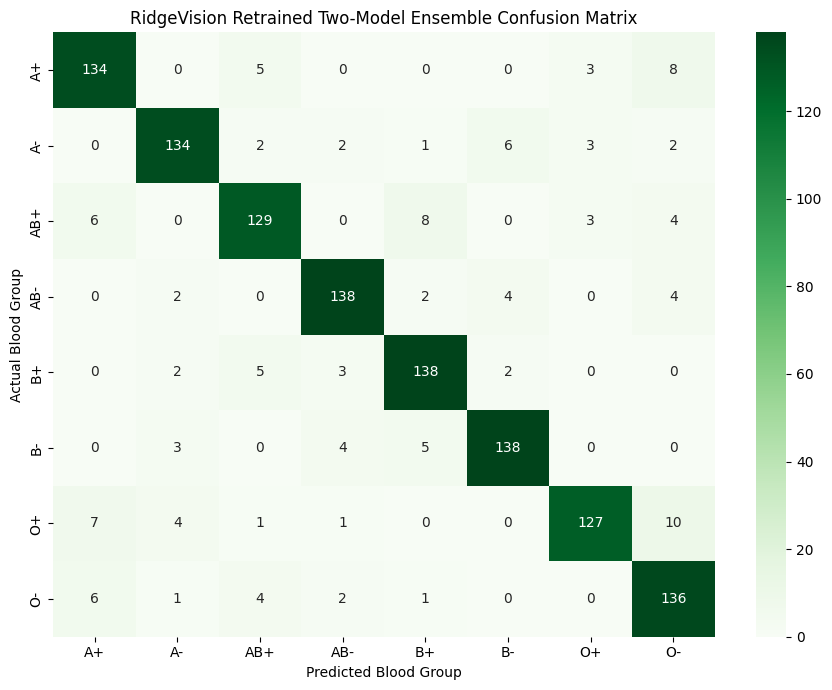

In [18]:
# =========================
# CONFUSION MATRIX
# =========================

cm = confusion_matrix(y_test, test_pred_ensemble)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=CLASS_LABELS,
    yticklabels=CLASS_LABELS,
)
plt.xlabel('Predicted Blood Group')
plt.ylabel('Actual Blood Group')
plt.title('RidgeVision Retrained Two-Model Ensemble Confusion Matrix')
plt.tight_layout()
plt.savefig(REPORT_DIR / 'ridgevision_retrained_ensemble_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [19]:
# =========================
# SINGLE IMAGE ENSEMBLE PREDICTION
# =========================

def predict_image_ensemble(image_path):
    image_88 = np.expand_dims(load_cnn_image(image_path, 224), axis=0)
    texture_88 = np.expand_dims(extract_texture_features_88(image_path), axis=0)

    image_91 = np.expand_dims(load_cnn_image(image_path, 300), axis=0)
    texture_91 = np.expand_dims(extract_texture_features_91(image_path), axis=0)

    pred_88 = result_88['model']({'image_input': image_88, 'texture_input': texture_88}, training=False).numpy()[0]
    pred_91 = result_91['model']({'image_input': image_91, 'texture_input': texture_91}, training=False).numpy()[0]

    pred = ensemble_probabilities(pred_88[None, :], pred_91[None, :], best_weight)[0]
    predicted_index = int(np.argmax(pred))

    return {
        'predicted_class': CLASS_LABELS[predicted_index],
        'confidence': float(pred[predicted_index] * 100),
        'model_88_class': CLASS_LABELS[int(np.argmax(pred_88))],
        'model_91_class': CLASS_LABELS[int(np.argmax(pred_91))],
        'all_probabilities': {
            CLASS_LABELS[i]: float(pred[i] * 100)
            for i in range(len(CLASS_LABELS))
        },
    }

sample_image = str(DATASET_DIR / 'A+' / 'cluster_0_1554.BMP')
print('Sample image:', sample_image)
print(predict_image_ensemble(sample_image))

Sample image: /kaggle/input/datasets/abhiramshibaraya/fingerprint-based-blood-group-detection/dataset/A+/cluster_0_1554.BMP
{'predicted_class': 'A+', 'confidence': 91.83565521240234, 'model_88_class': 'A+', 'model_91_class': 'A+', 'all_probabilities': {'A+': 91.83565521240234, 'A-': 0.004388895817101002, 'AB+': 0.000571912678424269, 'AB-': 0.026266638189554214, 'B+': 2.2686057491227984e-05, 'B-': 0.1449493020772934, 'O+': 7.901906967163086, 'O-': 0.08625490218400955}}


## Final Output Files

This notebook saves:

- `/kaggle/working/ridgevision_b0_88_style_best.keras`
- `/kaggle/working/ridgevision_b3_91_style_best.keras`
- `/kaggle/working/report_images/ridgevision_retrained_ensemble_confusion_matrix.png`
- `/kaggle/working/report_images/ridgevision_train_both_ensemble_report.txt`

If the ensemble is lower than the best individual model, report the best individual model instead. An ensemble improves only when the two models make different mistakes.